# DICOM Preprocessing Pipeline

Raw mammogram DICOMs have wildly varying bit depths, dynamic ranges,
and resolutions.  Before any model can consume them, we need a
consistent format:

1. **Load** the DICOM and normalise to `[0, 1]` float32.
2. **Segment and crop the breast** - an Otsu threshold plus a largest-connected-component mask isolates the breast, drops the black border, and removes the burned-in laterality/view marker
   (e.g. the bright "L CC" film label).  Left in, that marker is the
   highest-contrast object in the frame and the CNN learns it as a
   shortcut for laterality — visible in Grad-CAM as a hot spot on the
   label — so we strip it here.
3. **CLAHE** — Contrast Limited Adaptive Histogram Equalisation
   (clip limit 2.0, 8×8 tiles) to reveal subtle tissue detail.
4. **Resize** to a fixed 224×224 square (matching ImageNet input).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from src.data.preprocessing import (
    load_dicom,
    segment_breast,
    breast_bbox,
    apply_clahe,
    resize,
    preprocess,
)

DICOM_DIR = Path("../data/cbis-ddsm/cbis_ddsm")

## DICOM sample

File:	e35e53fd-5312-406e-ad9f-4c11e725e53f.dcm
Shape:	(4808, 3024)
Dtype:	uint16
Min:	0
Max:	65535


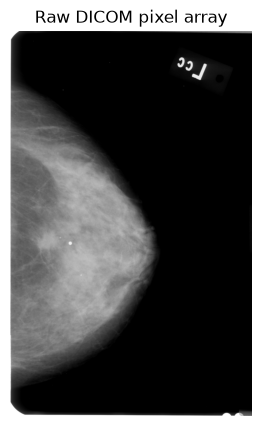

In [2]:
import pydicom

import pandas as pd
from src.data.cbis_ddsm import DICOMPathResolver

# Use the resolver so we get a genuine full mammogram, not a crop or mask
df = pd.read_csv("../data/cbis-ddsm/mass_case_description_train_set.csv")
resolver = DICOMPathResolver(DICOM_DIR)
sample = df.iloc[0]
image_path, _, _ = resolver.resolve_case(
    sample["image file path"],
    sample["cropped image file path"],
    sample["ROI mask file path"],
)

ds = pydicom.dcmread(str(image_path))
raw = ds.pixel_array
print(f"File:\t{image_path.name}")
print(f"Shape:\t{raw.shape}")
print(f"Dtype:\t{raw.dtype}")
print(f"Min:\t{raw.min()}")
print(f"Max:\t{raw.max()}")

plt.figure(figsize=(5, 5))
plt.imshow(raw, cmap="gray")
plt.title("Raw DICOM pixel array")
plt.axis("off")
plt.show()

## Step 1, normalise to [0, 1]

Shape:	(4808, 3024)
Dtype:	float32
Min:	0.0000
Max:	1.0000


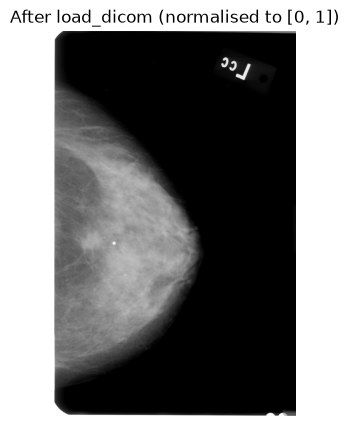

In [3]:
arr = load_dicom(image_path)
print(f"Shape:\t{arr.shape}")
print(f"Dtype:\t{arr.dtype}")
print(f"Min:\t{arr.min():.4f}")
print(f"Max:\t{arr.max():.4f}")

plt.figure(figsize=(5, 5))
plt.imshow(arr, cmap="gray")
plt.title("After load_dicom (normalised to [0, 1])")
plt.axis("off")
plt.show()

## Step 2, Segment and crop the breast

In order to achieve Grad-CAM vs ROI auditability, I need to train on the full image instead of the cropped lesion.

`segment_breast` uses Otsu thresholding and keeps the largest connected component, removing the burned-in laterality marker and black border that would otherwise dominate the CNN's attention. `breast_bbox` returns the tight crop box, which is also reused when cropping the ROI mask so heatmaps and lesion outlines stay registered.

Original:	(4808, 3024)
Cropped:	(4808, 1948)


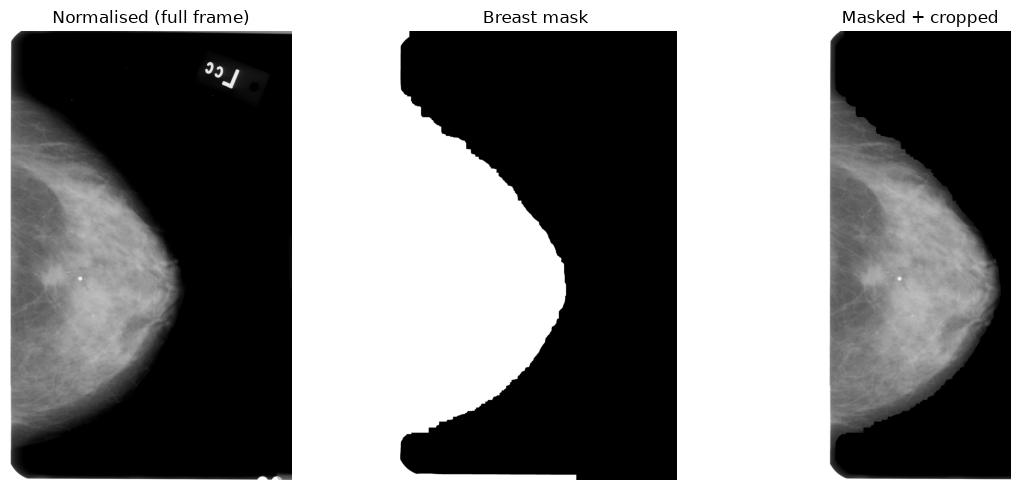

In [4]:
mask = segment_breast(arr)
y0, y1, x0, x1 = breast_bbox(mask)
arr_cropped = (arr * mask)[y0:y1, x0:x1]
print(f"Original:\t{arr.shape}")
print(f"Cropped:\t{arr_cropped.shape}")

fig, axes = plt.subplots(1, 3, figsize=(12, 5))
axes[0].imshow(arr, cmap="gray")
axes[0].set_title("Normalised (full frame)")
axes[0].axis("off")

axes[1].imshow(mask, cmap="gray")
axes[1].set_title("Breast mask")
axes[1].axis("off")

axes[2].imshow(arr_cropped, cmap="gray")
axes[2].set_title("Masked + cropped")
axes[2].axis("off")

plt.tight_layout()
plt.show()

## Step 3, CLAHE Constrast Enhancement

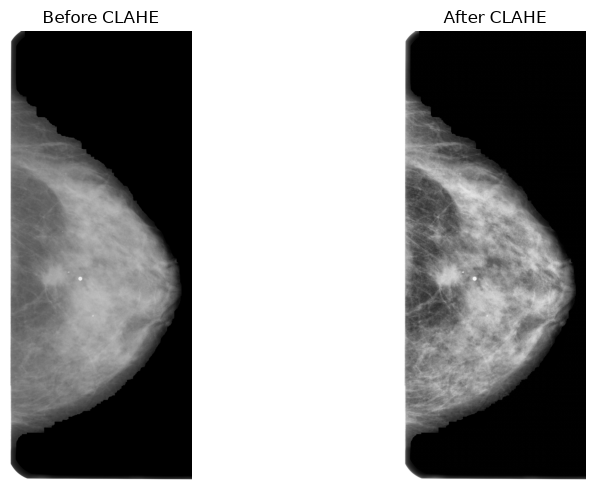

In [5]:
arr_clahe = apply_clahe(arr_cropped)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(arr_cropped, cmap="gray")
axes[0].set_title("Before CLAHE")
axes[0].axis("off")

axes[1].imshow(arr_clahe, cmap="gray")
axes[1].set_title("After CLAHE")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## Step 4, Resize to 224 x 224

Final shape:	(224, 224)


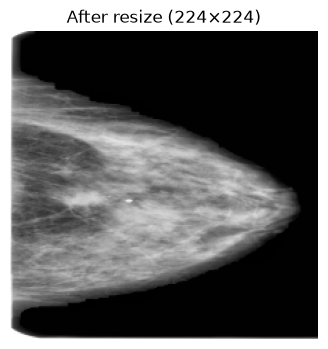

In [6]:
arr_resized = resize(arr_clahe, size=224)
print(f"Final shape:\t{arr_resized.shape}")

plt.figure(figsize=(4, 4))
plt.imshow(arr_resized, cmap="gray")
plt.title("After resize (224×224)")
plt.axis("off")
plt.show()